In [1]:
import torch as pt


mols_test = pt.load('./data/mine/test_11499.pt')
print(len(mols_test))
mols_all = pt.load('./data/mine/mols_all.pt')
print(len(mols_all))

/tmp/ipykernel_1872196/1496347472.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mols_test = pt.load('./data/mine/test_11499.pt')


11499


/tmp/ipykernel_1872196/1496347472.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mols_all = pt.load('./data/mine/mols_all.pt')


2253216


In [2]:
# 统计词频
import numpy as np


mols_train = mols_all[:232826]
count_list = np.zeros(1000)
for mol in mols_train:
    tmp_list = np.zeros(1000)
    for mz in mol.mz:
        tmp_list[int(mz)] = 1
    count_list += tmp_list

count_list += 1  
print(count_list.shape)

(1000,)


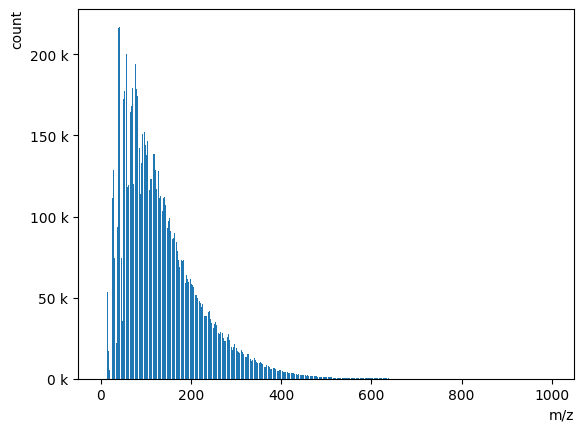

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig = plt.figure()
ax = fig.add_subplot()
ax.bar(np.arange(1000), count_list)
ax.set_xlabel('m/z', loc='right')
ax.set_ylabel('count', loc='top')
# ax.legend()
def formatter(x, pos):
    return f'{int(x/1000)} k'
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatter))
# fig.savefig('count_bar.svg', format='svg', dpi=500)

In [4]:
import numpy as np


# 生成负采样概率
pow_frequency = np.array(count_list) ** 0.75
neg_prob = pow_frequency / pow_frequency.sum()
print(neg_prob.shape)
# 生成下采样概率
mzs_freq = np.array(count_list)
mzs_freq = mzs_freq / np.sum(mzs_freq)
t = 1e-3
keep_prob = np.array([np.sqrt(t/f) + t/f for f in mzs_freq])

(1000,)


In [5]:
from torch.utils.data import DataLoader
from utils.data import SpecDataset, collate_fun_emb
import numpy as np


def collate_fun(keep_prob:np.array, neg_prob:np.array, neg_num:int=5, min_len_mz:int=10, min_inten:float=0.01):
    neg_choice = np.arange(neg_prob.shape[0])
    def collate_fn(batch):
        # con: context, cen: center
        mzs_con, inten_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg = [], [], [], [], [], [], []
        max_len = max([len(mz) for mz, _ in batch])
        idx = 0
        for mz, inten in batch:
            len_mz = len(mz)
            if len_mz >= min_len_mz: # 移除峰的数量小于阈值的质谱 
                pad_num = max_len - len_mz
                pos_cen = []
                mask_down = np.random.random(len_mz) < keep_prob[mz]
                for i in range(len_mz):
                    if mask_down[i] and inten[i] > min_inten: # 如果没有被mask掉
                        mask_pos_down = np.array(mask_down)
                        mask_pos_down[i] = False
                        if np.any(mask_pos_down): # 上下文没有被全部mask掉
                            pos_cen.append(mz[i])
                            masks_con.append(np.pad(mask_pos_down, (0, pad_num)))
                if len(pos_cen) == 0: # 整个质谱中的中心词都被mask掉了
                    continue   
                mzs_con.append(np.pad(mz, (0, pad_num)))
                inten_con.append(np.pad(inten, (0, pad_num)))
                poss_cen.extend(pos_cen)
                batch_idx.extend([idx] * len(pos_cen))
                idx += 1
                neg_cen = np.random.choice(neg_choice, (len(pos_cen), neg_num), p=neg_prob)
                mask_neg = neg_cen != np.array(pos_cen)[:, np.newaxis]
                negs_cen.append(neg_cen)
                masks_neg.append(mask_neg)
        if len(mzs_con) == 0:
            return None
        mzs_con = pt.tensor(np.array(mzs_con), dtype=pt.long)
        inten_con = pt.tensor(np.array(inten_con), dtype=pt.float)
        masks_con = pt.tensor(np.array(masks_con), dtype=pt.bool)
        poss_cen = pt.tensor(np.array(poss_cen), dtype=pt.long)
        batch_idx = pt.tensor(np.array(batch_idx), dtype=pt.int)
        negs_cen = pt.tensor(np.concatenate(negs_cen), dtype=pt.long)
        masks_neg = pt.tensor(np.concatenate(masks_neg), dtype=pt.bool)
        return mzs_con, inten_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg
    return collate_fn


dataset_lib = SpecDataset(mols_all)
dataset_test = SpecDataset(mols_test)
loader_lib = DataLoader(dataset_lib, batch_size=1024, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
loader_test = DataLoader(dataset_test, batch_size=1024, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
dataset_train = SpecDataset(dataset_lib, mapping=np.arange(232826))
loader_train = DataLoader(dataset_train, batch_size=10, shuffle=True, 
                            num_workers=5, collate_fn=collate_fun(keep_prob, neg_prob))
num_batches = len(loader_train)

In [6]:
import torch as pt
import torch.nn as nn
import torch.nn.functional as F


class IntenMlp(nn.Module):
    def __init__(self, mlp_dim=256):
        super(IntenMlp, self).__init__()
        self.fc1 = nn.Linear(1, mlp_dim)
        self.fc2 = nn.Linear(mlp_dim, 1)
        self.a = nn.Parameter(pt.tensor(1.0))
        self.b = nn.Parameter(pt.tensor(0.001))

    def forward(self, x):
        # 将x的形状调整为 [batch_size, num_features, 1] 以便广播    
        x = x.unsqueeze(-1) 
        x = self.fc2(F.relu(self.fc1(x))).squeeze()
        x = self.a * F.sigmoid(x) + self.b
        return x

In [7]:
import torch.optim as optim
from utils.model import Spec2Emb, Linear_Scheduler
import torch.nn as nn
import torch.nn.functional as F


class Spec2Emb(nn.Module):
    def __init__(self, num_emb:int=1000, emb_dim:int=512, mlp_dim:int=256):
        super(Spec2Emb, self).__init__()
        self.max_exp = 6
        self.emb_con = nn.Embedding(
            num_embeddings=num_emb,
            embedding_dim=emb_dim,
        )
        self.emb_cen = nn.Embedding(
            num_embeddings=num_emb,
            embedding_dim=emb_dim,
        )
        self.trip_loss = nn.TripletMarginLoss(margin=1.0, p=2)
        self.burger = IntenMlp(mlp_dim)
        
    def _compute_embedding(self, data, power, inten_mode:str='burger'):
        mzs, intens, masks = data  # [batch, seq]
        embs = self.emb_cen(mzs) # [batch, seq, emb_dim]
        # intens [batch, seq]
        embs = embs * masks.unsqueeze(-1)
        if inten_mode == 'burger':
            intens = self.burger(intens)
            embs = (embs * intens.unsqueeze(-1)).sum(dim=1) / intens.sum(dim=1, keepdim=True)
        elif inten_mode == 'pow':
            intens = pt.pow(intens, power)
            embs = (embs * intens.unsqueeze(-1)).sum(dim=1)
        return embs

    def forward(self, data, mode:str='train', power:float=0.5, inten_mode:str='pow'):
        if mode == 'train': 
            # masks_con:
            mzs_con, intens_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg = data
            embs_con = self.emb_con(mzs_con)        # [batch, seq, emb_dim]
            embs_pos = self.emb_cen(poss_cen)     # [B, emb_dim]
            embs_neg = self.emb_cen(negs_cen)      # [B, neg_num, emb_dim]
            embs_neg *= masks_neg.unsqueeze(-1)
            # for every cen word its context words
            embs_con = embs_con[batch_idx] * masks_con.unsqueeze(-1)
            if inten_mode == 'burger':
                intens_con = self.burger(intens_con) # [B, seq, 1]
            embs_con = embs_con * intens_con[batch_idx].unsqueeze(-1)
            intens_con_sum = (intens_con[batch_idx] * masks_con).sum(dim=1).unsqueeze(-1)
            embs_con = embs_con.sum(dim=1) / intens_con_sum
            # embs_con = embs_con.sum(dim=1) / masks_con.sum(dim=1).unsqueeze(-1) # [B, emb_dim]
            
            pos_score = (embs_con * embs_pos).sum(dim=-1) # 点积
            pos_score = pt.clamp(pos_score, max=self.max_exp, min=-self.max_exp)
            pos_score = -F.logsigmoid(pos_score)
            neg_score = pt.bmm(embs_neg, embs_con.unsqueeze(-1)).squeeze(-1) #
            neg_score = pt.clamp(neg_score, max=self.max_exp, min=-self.max_exp)
            neg_score = -F.logsigmoid(-neg_score).sum(dim=-1)
            return (pos_score + neg_score).sum() 
        elif mode == 'emb': # emb模式下的masks只mask掉了padding             
            return self._compute_embedding(data, power, inten_mode)
        elif mode == 'finetune':
            data_mea, data_pre_hit, data_pre_nhit = data
            embs_mea = self._compute_embedding(data_mea, power)
            embs_pre_hit = self._compute_embedding(data_pre_hit, power)
            embs_pre_nhit = self._compute_embedding(data_pre_nhit, power)
            # batchsize, emb_dim
            embs_mea = F.normalize(embs_mea, p=2, dim=-1)
            embs_pre_hit = F.normalize(embs_pre_hit, p=2, dim=-1)
            embs_pre_nhit = F.normalize(embs_pre_nhit, p=2, dim=-1)
            # batchsize
            loss = self.trip_loss(embs_mea, embs_pre_hit, embs_pre_nhit)
            return loss
        else:
            raise ValueError('mode not exist')


gpu = 6
model = Spec2Emb(mlp_dim=256).to(gpu)

epochs = 10
lr = 0.025
optimizer = optim.Adam(model.parameters(), lr=lr)

In [8]:
from tqdm import tqdm
from utils.tools import gen_embeddings, build_idx, evaluate, save_model


def gen_embeddings(model:nn.Module, loader:DataLoader, gpu:int, power:float=0.5, inten_mode:str='burger'):
    model.eval()
    embs = []
    with pt.no_grad():
        for mzs_con, intens_con, masks in loader:
            data = [d.to(gpu) for d in (mzs_con, intens_con, masks)]
            emb = model(tuple(data), mode='emb', power=power, inten_mode=inten_mode).detach().cpu().numpy()
            embs.append(emb)
    pt.cuda.empty_cache()
    embs = np.concatenate(embs, axis=0)
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)
    return embs


model_name = 'mlp_256_divide_inten'
f = open(model_name + '.txt', 'w')
max_metrics = {'expand': [0, 0], 'insilico': [0, 0]}
for epoch in range(epochs):
    print(f'==================================Train_epoch{epoch+1}======================================')
    model.train()
    train_loss = []
    for i, Data in enumerate(tqdm(loader_train, unit='batch')):
        data = [d.to(gpu) for d in Data]
        optimizer.zero_grad()
        loss = model(data, inten_mode='burger')
        train_loss.append(loss.item())
        loss.backward()
        optimizer.step()
        if (i+1) %5000 ==0:
            loss = np.mean(train_loss)
            print(f'Total Loss: {loss}')
            train_loss = []
    
    print(f'===================================Test_epoch{epoch+1}======================================')
    f.write('\nTest_epoch%d\n' % (epoch+1))
    embeddings_lib = gen_embeddings(model, loader_lib, gpu)
    embeddings_test = gen_embeddings(model, loader_test, gpu)
    I_expand, _ = build_idx(embeddings_lib, embeddings_test, gpu)
    top1_expand, top10_expand = evaluate(mols_test, I_expand, mols_all, f, 'Expanded')
    if top1_expand > max_metrics['expand'][0] and top10_expand > max_metrics['expand'][1]:
        max_metrics['expand'] = [top1_expand, top10_expand]
        save_model(model, model_name, epoch)
    I_insilico, _ = build_idx(embeddings_lib[:2146690], embeddings_test, gpu)
    top1_insilico, top10_insilico = evaluate(mols_test, I_insilico, mols_all, f, 'In-silico')
    if top1_insilico > max_metrics['insilico'][0] and top10_insilico > max_metrics['insilico'][1]:
        max_metrics['insilico'] = [top1_insilico, top10_insilico]
        save_model(model, model_name, epoch)
    print(f'================================================================================================')
f.close()

==================================Train_epoch1======================================


 22%|██▏       | 5006/23283 [01:11<04:48, 63.42batch/s]

Total Loss: 1732.2833722412108


 43%|████▎     | 10015/23283 [02:20<02:56, 75.09batch/s]

Total Loss: 1652.6402901611327


...

 86%|████████▌ | 20012/23283 [04:37<00:46, 70.81batch/s]

Total Loss: 1647.84219921875


100%|██████████| 23283/23283 [05:23<00:00, 72.04batch/s]

===================================Test_epoch10======================================


Searching time:  0:00:01.562850
Expanded library
Top1 hit rate: 8.62%
Top10 hit rate: 25.32%
Searching time:  0:00:01.495430
In-silico library
Top1 hit rate: 8.79%
Top10 hit rate: 25.57%


In [ ]:
pt.cuda.empty_cache()